In [1]:
import cv2
import numpy as np
import time
from pathlib import Path
from matplotlib import pyplot as plt

try:
    import cupy as cp
    CUPY_IMPORT_ERROR = None
except Exception as e:
    cp = None
    CUPY_IMPORT_ERROR = e

In [2]:
def cv2_imread_unicode(path, flags=cv2.IMREAD_COLOR):
    """Чтение изображения OpenCV с поддержкой русских букв в пути."""
    path = str(path)
    if not Path(path).exists():
        return None
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, flags)


def cv2_imwrite_unicode(path, image):
    """Сохранение изображения OpenCV с поддержкой русских букв в пути."""
    path = str(path)
    suffix = Path(path).suffix
    if suffix == "":
        raise ValueError("У выходного файла должно быть расширение, например .png")

    ok, encoded = cv2.imencode(suffix, image)
    if not ok:
        return False
    encoded.tofile(path)
    return Path(path).exists()

In [3]:
def harris_corner_detection(image, threshold):
    # Преобразуем изображение в тип float32
    image = np.float32(image)

    # Вычисляем градиенты
    Ix = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Вычисляем элементы матрицы A
    Ixx = Ix * Ix
    Ixy = Ix * Iy
    Iyy = Iy * Iy

    # Применяем гауссово размытие
    Ixx = cv2.GaussianBlur(Ixx, (5, 5), sigmaX=1)
    Ixy = cv2.GaussianBlur(Ixy, (5, 5), sigmaX=1)
    Iyy = cv2.GaussianBlur(Iyy, (5, 5), sigmaX=1)

    # Формируем матрицу A и вычисляем R
    det_A = Ixx * Iyy - Ixy * Ixy
    trace_A = Ixx + Iyy
    R = det_A - 0.04 * (trace_A ** 2)

    # Нахождение углов
    corners = np.zeros_like(R)
    corners[R > threshold] = 255

    return corners.astype(np.uint8)

In [4]:
def main(source_image_path, threshold, output_image_path):
    # Чтение изображения с поддержкой русских букв в пути
    image = cv2_imread_unicode(source_image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"Не удалось открыть изображение: {source_image_path}")

    cpu_output_path = output_image_path + "_cpu.png"
    gpu_output_path = output_image_path + "_gpu.png"

    # Запуск алгоритма без GPU
    start_time = time.time()
    corners_cpu = harris_corner_detection(image, threshold)
    cpu_time = time.time() - start_time

    # Отметка углов на исходном изображении
    output_image_cpu = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    output_image_cpu[corners_cpu > 0] = [0, 0, 255]  # Красные углы

    # Сохранение результата CPU
    if not cv2_imwrite_unicode(cpu_output_path, output_image_cpu):
        raise OSError(f"Не удалось сохранить изображение: {cpu_output_path}")

    # Запуск алгоритма с GPU
    if cp is None:
        print(f"CuPy недоступен, GPU-часть пропущена. Ошибка: {CUPY_IMPORT_ERROR}")
        corners_gpu = None
        gpu_time = None
        result_match = None
    else:
        image_gpu = cp.asarray(image)
        start_time = time.time()
        corners_gpu = harris_corner_detection(cp.asnumpy(image_gpu), threshold)
        gpu_time = time.time() - start_time

        # Отметка углов на исходном изображении
        output_image_gpu = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        output_image_gpu[corners_gpu > 0] = [0, 0, 255]  # Красные углы

        # Сохранение результата GPU
        if not cv2_imwrite_unicode(gpu_output_path, output_image_gpu):
            raise OSError(f"Не удалось сохранить изображение: {gpu_output_path}")

        # Сравнение результатов
        result_match = np.array_equal(corners_cpu, corners_gpu)

    # Вывод результатов
    print(f"Execution time without GPU: {cpu_time:.4f} seconds")
    if gpu_time is not None:
        print(f"Execution time with GPU: {gpu_time:.4f} seconds")
        print(f"Results match: {result_match}")

    return {
        "cpu_time": cpu_time,
        "gpu_time": gpu_time,
        "result_match": result_match,
        "cpu_output": cpu_output_path,
        "gpu_output": gpu_output_path if gpu_time is not None else None,
    }

## Параметры запуска

In [8]:
    source_image_path = input("Введите путь к исходному изображению: ")
    threshold = float(input("Введите значение порога для обнаружения углов: "))
    output_image_path = input("Введите путь для сохранения выходного изображения: ")
print("Исходное изображение существует:", Path(source_image_path).exists())

Исходное изображение существует: True


## Запуск алгоритма

In [9]:
results = main(source_image_path, threshold, output_image_path)
results

Execution time without GPU: 0.0739 seconds
Execution time with GPU: 0.0831 seconds
Results match: True


{'cpu_time': 0.07385706901550293,
 'gpu_time': 0.08313131332397461,
 'result_match': True,
 'cpu_output': 'C:\\Users\\user\\Desktop\\учеба\\Мага 1 курс\\HPC\\harris_cpu.png',
 'gpu_output': 'C:\\Users\\user\\Desktop\\учеба\\Мага 1 курс\\HPC\\harris_gpu.png'}

## Просмотр результата

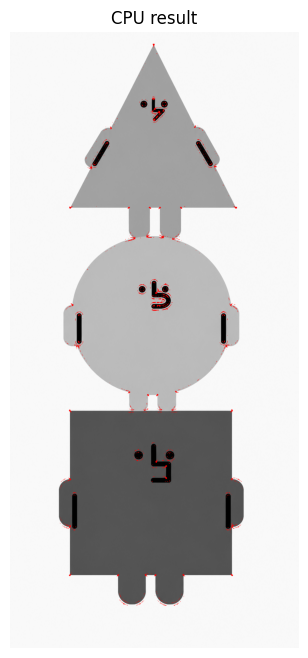

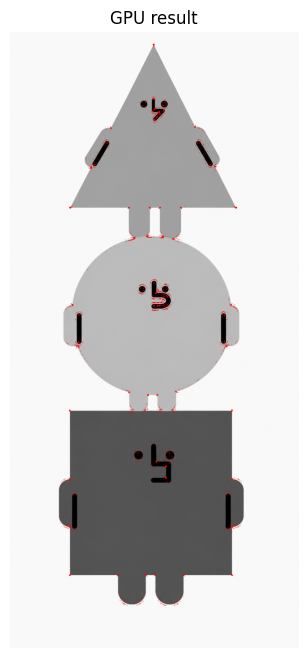

In [11]:
cpu_result = cv2_imread_unicode(results["cpu_output"], cv2.IMREAD_COLOR)

if cpu_result is None:
    raise FileNotFoundError(f"Не удалось открыть результат CPU: {results['cpu_output']}")

cpu_result = cv2.cvtColor(cpu_result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.title("CPU result")
plt.imshow(cpu_result)
plt.axis("off")
plt.show()

if results["gpu_output"] is not None:
    gpu_result = cv2_imread_unicode(results["gpu_output"], cv2.IMREAD_COLOR)

    if gpu_result is None:
        raise FileNotFoundError(f"Не удалось открыть результат GPU: {results['gpu_output']}")

    gpu_result = cv2.cvtColor(gpu_result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.title("GPU result")
    plt.imshow(gpu_result)
    plt.axis("off")
    plt.show()